#This case requires to develop a customer segmentation to define marketing strategy. The sample Dataset summarizes the usage behavior of about 9000 active credit card holders during the last 6 months. The file is at a customer level with 18 behavioral variables.

In [77]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ccdata' dataset.
Path to dataset files: /kaggle/input/ccdata


In [78]:
import os
print("Files:", os.listdir(path))

Files: ['CC GENERAL.csv']


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv(os.path.join(path, "CC GENERAL.csv"))
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


#Data cleaning


1.   check for null values
2.   check for duplicated values




In [80]:
#null
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [81]:
# Drop rows with null values

df = df.dropna()

In [82]:
#duplicated

df.duplicated().sum()

np.int64(0)

In [83]:
df.count()

,0
CUST_ID,8636
BALANCE,8636
BALANCE_FREQUENCY,8636
PURCHASES,8636
ONEOFF_PURCHASES,8636
INSTALLMENTS_PURCHASES,8636
CASH_ADVANCE,8636
PURCHASES_FREQUENCY,8636
ONEOFF_PURCHASES_FREQUENCY,8636
PURCHASES_INSTALLMENTS_FREQUENCY,8636


In [84]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12


# Feature engineering


*   balance to credit ratio
*   



In [85]:
# Feature Engineering for Credit Card Dataset

import pandas as pd
import numpy as np


# Balance utilization: how much of credit limit is being used
df['BALANCE_TO_CREDIT_RATIO'] = df['BALANCE'] / df['CREDIT_LIMIT'].replace(0, np.nan)

# Payment behavior: how much more than the minimum they pay
df['PAYMENT_TO_MIN_RATIO'] = df['PAYMENTS'] / df['MINIMUM_PAYMENTS'].replace(0, np.nan)

# What fraction of purchases are one-off vs installment
df['ONEOFF_PURCHASE_RATIO'] = df['ONEOFF_PURCHASES'] / df['PURCHASES'].replace(0, np.nan)
df['INSTALLMENT_PURCHASE_RATIO'] = df['INSTALLMENTS_PURCHASES'] / df['PURCHASES'].replace(0, np.nan)

# Cash advance reliance relative to total activity
df['CASH_ADVANCE_TO_CREDIT_RATIO'] = df['CASH_ADVANCE'] / df['CREDIT_LIMIT'].replace(0, np.nan)

# Average purchase per transaction
df['AVG_PURCHASE_PER_TRX'] = df['PURCHASES'] / df['PURCHASES_TRX'].replace(0, np.nan)

# Average cash advance per transaction
df['AVG_CASH_ADVANCE_PER_TRX'] = df['CASH_ADVANCE'] / df['CASH_ADVANCE_TRX'].replace(0, np.nan)

# Monthly spending intensity (purchases per month of tenure)
df['MONTHLY_PURCHASES'] = df['PURCHASES'] / df['TENURE'].replace(0, np.nan)

# Monthly cash advance intensity
df['MONTHLY_CASH_ADVANCE'] = df['CASH_ADVANCE'] / df['TENURE'].replace(0, np.nan)



# --- Fill NaNs from divisions by zero ---
df.fillna(0, inplace=True)

print(f"Original features: 18")
print(f"New features added: {df.shape[1] - 18}")
print(f"Total features: {df.shape[1]}")
print("\nNew columns:")
print([c for c in df.columns if c not in ['CUST_ID','BALANCE','BALANCE_FREQUENCY','PURCHASES',
    'ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES','CASH_ADVANCE','PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY','PURCHASES_INSTALLMENTS_FREQUENCY','CASH_ADVANCE_FREQUENCY',
    'CASH_ADVANCE_TRX','PURCHASES_TRX','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS',
    'PRC_FULL_PAYMENT','TENURE']])

Original features: 18
New features added: 9
Total features: 27

New columns:
['BALANCE_TO_CREDIT_RATIO', 'PAYMENT_TO_MIN_RATIO', 'ONEOFF_PURCHASE_RATIO', 'INSTALLMENT_PURCHASE_RATIO', 'CASH_ADVANCE_TO_CREDIT_RATIO', 'AVG_PURCHASE_PER_TRX', 'AVG_CASH_ADVANCE_PER_TRX', 'MONTHLY_PURCHASES', 'MONTHLY_CASH_ADVANCE']


In [86]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,TENURE,BALANCE_TO_CREDIT_RATIO,PAYMENT_TO_MIN_RATIO,ONEOFF_PURCHASE_RATIO,INSTALLMENT_PURCHASE_RATIO,CASH_ADVANCE_TO_CREDIT_RATIO,AVG_PURCHASE_PER_TRX,AVG_CASH_ADVANCE_PER_TRX,MONTHLY_PURCHASES,MONTHLY_CASH_ADVANCE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,...,12,0.040901,1.446508,0.0,1.0,0.000000,47.700000,0.000000,7.950000,0.000000
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,...,12,0.457495,3.826241,0.0,0.0,0.920421,0.000000,1610.736371,0.000000,536.912124
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,...,12,0.332687,0.991682,1.0,0.0,0.000000,64.430833,0.000000,64.430833,0.000000
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,...,12,0.681429,2.771075,1.0,0.0,0.000000,16.000000,0.000000,1.333333,0.000000
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,...,12,1.005460,0.581601,0.0,1.0,0.000000,166.660000,0.000000,111.106667,0.000000


# Now we will check for outliers
## this is so the model isnt unrealistically biased

In [87]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,TENURE,BALANCE_TO_CREDIT_RATIO,PAYMENT_TO_MIN_RATIO,ONEOFF_PURCHASE_RATIO,INSTALLMENT_PURCHASE_RATIO,CASH_ADVANCE_TO_CREDIT_RATIO,AVG_PURCHASE_PER_TRX,AVG_CASH_ADVANCE_PER_TRX,MONTHLY_PURCHASES,MONTHLY_CASH_ADVANCE
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,...,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,1601.224893,0.895035,1025.433874,604.901438,420.843533,994.175523,0.496000,0.205909,0.368820,0.137604,...,11.534391,0.397722,9.351080,0.380642,0.392450,0.252674,72.691437,207.607595,88.015149,90.251544
std,2095.571300,0.207697,2167.107984,1684.307803,917.245182,2121.458303,0.401273,0.300054,0.398093,0.201791,...,1.310984,0.390256,120.293843,0.424784,0.429121,1.288724,153.006574,528.900363,183.043461,195.227264
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.000000,0.000000,0.000730,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,148.095189,0.909091,43.367500,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,...,12.000000,0.047409,0.957560,0.000000,0.000000,0.000000,12.319286,0.000000,3.750000,0.000000
50%,916.855459,1.000000,375.405000,44.995000,94.785000,0.000000,0.500000,0.083333,0.166667,0.000000,...,12.000000,0.318259,2.170678,0.120507,0.188778,0.000000,41.633237,0.000000,33.212500,0.000000
75%,2105.195853,1.000000,1145.980000,599.100000,484.147500,1132.385490,0.916667,0.333333,0.750000,0.250000,...,12.000000,0.725751,6.262127,0.869388,0.984600,0.359789,78.744185,247.880491,99.876250,101.015833
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,...,12.000000,15.909951,6840.528861,1.803692,2.963815,113.535593,5981.666667,14836.451410,4086.630833,3928.100980


In [88]:
from scipy.stats import mstats


cap_cols = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
    'CASH_ADVANCE_TO_CREDIT_RATIO', 'AVG_PURCHASE_PER_TRX',
    'AVG_CASH_ADVANCE_PER_TRX', 'MONTHLY_PURCHASES', 'MONTHLY_CASH_ADVANCE'
]

for col in cap_cols:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)

# Recalculate log transforms after capping
for col in ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']:
    df[f'LOG_{col}'] = np.log1p(df[col])

In [89]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,CASH_ADVANCE_TO_CREDIT_RATIO,AVG_PURCHASE_PER_TRX,AVG_CASH_ADVANCE_PER_TRX,MONTHLY_PURCHASES,MONTHLY_CASH_ADVANCE,LOG_BALANCE,LOG_PURCHASES,LOG_CASH_ADVANCE,LOG_CREDIT_LIMIT,LOG_PAYMENTS
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,...,0.000000,47.700000,0.000000,7.950000,0.000000,3.735304,4.568506,0.000000,6.908755,5.312231
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,...,0.920421,0.000000,1610.736371,0.000000,536.912124,8.071989,0.000000,8.770896,8.853808,8.319725
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,...,0.000000,64.430833,0.000000,64.430833,0.000000,7.822504,6.651791,0.000000,8.922792,6.434654
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,...,0.000000,16.000000,0.000000,1.333333,0.000000,6.707735,2.833213,0.000000,7.090910,6.521114
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,...,0.000000,166.660000,0.000000,111.106667,0.000000,7.501540,7.196147,0.000000,7.496097,7.244983


In [90]:
df = df.drop('CUST_ID', axis=1)

#Checking for multi-collinearity


*   correlation matrix
*   Vif score



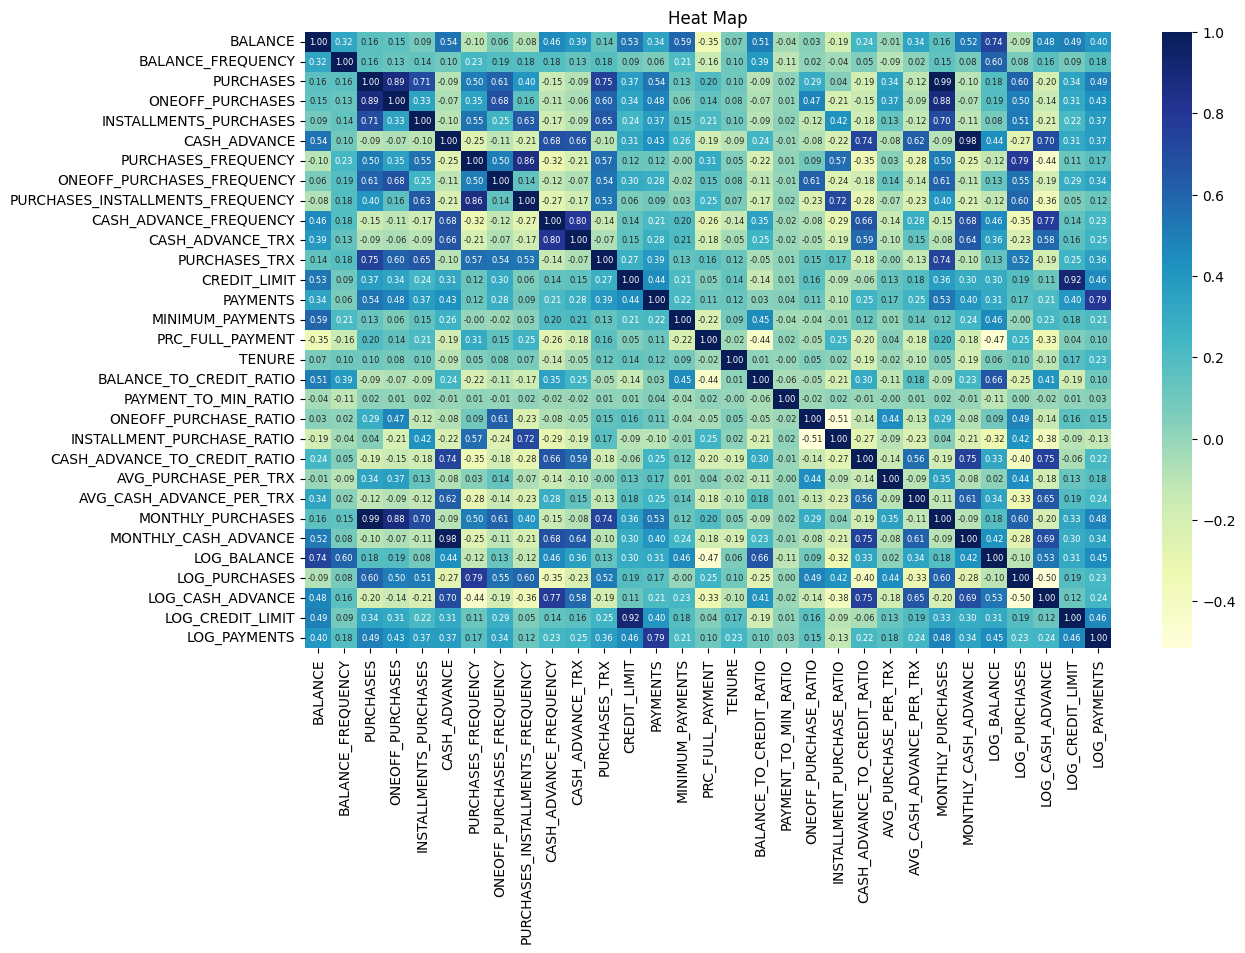

In [91]:
import seaborn as sns

corr = df.corr()

# Create the heatmap
plt.figure(figsize=(13, 8))
plt.title('Heat Map')
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", annot_kws={'size': 6})
plt.show()

Vif score the purpose of this is to find which variables are highly redundant. When a dataset has features that are highly correlated it makes clustering unreliable. High collinearity makes other factors weaker

In [92]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df)
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

                            Variable         VIF
0                              const  676.543104
1                            BALANCE    4.958044
2                  BALANCE_FREQUENCY    2.329654
3                          PURCHASES  174.422059
4                   ONEOFF_PURCHASES   26.205484
5             INSTALLMENTS_PURCHASES   12.380465
6                       CASH_ADVANCE   55.152275
7                PURCHASES_FREQUENCY   16.874448
8         ONEOFF_PURCHASES_FREQUENCY    5.925275
9   PURCHASES_INSTALLMENTS_FREQUENCY   10.851295
10            CASH_ADVANCE_FREQUENCY    5.679094
11                  CASH_ADVANCE_TRX    3.652845
12                     PURCHASES_TRX    3.488627
13                      CREDIT_LIMIT    7.425433
14                          PAYMENTS    4.329015
15                  MINIMUM_PAYMENTS    1.762718
16                  PRC_FULL_PAYMENT    1.797385
17                            TENURE    2.363776
18           BALANCE_TO_CREDIT_RATIO    3.147784
19              PAYM

In [93]:
# Check correlations among high VIF features
high_vif_cols = ['PURCHASES', 'MONTHLY_PURCHASES', 'CASH_ADVANCE',
                 'MONTHLY_CASH_ADVANCE', 'LOG_PURCHASES', 'ONEOFF_PURCHASES']

corr_matrix = df[high_vif_cols].corr()
print(corr_matrix)

                      PURCHASES  MONTHLY_PURCHASES  CASH_ADVANCE  \
PURCHASES              1.000000           0.994531     -0.094165   
MONTHLY_PURCHASES      0.994531           1.000000     -0.090298   
CASH_ADVANCE          -0.094165          -0.090298      1.000000   
MONTHLY_CASH_ADVANCE  -0.097996          -0.089790      0.984027   
LOG_PURCHASES          0.598452           0.602073     -0.272811   
ONEOFF_PURCHASES       0.885332           0.883431     -0.067093   

                      MONTHLY_CASH_ADVANCE  LOG_PURCHASES  ONEOFF_PURCHASES  
PURCHASES                        -0.097996       0.598452          0.885332  
MONTHLY_PURCHASES                -0.089790       0.602073          0.883431  
CASH_ADVANCE                      0.984027      -0.272811         -0.067093  
MONTHLY_CASH_ADVANCE              1.000000      -0.275574         -0.069873  
LOG_PURCHASES                    -0.275574       1.000000          0.497382  
ONEOFF_PURCHASES                 -0.069873       0.4973

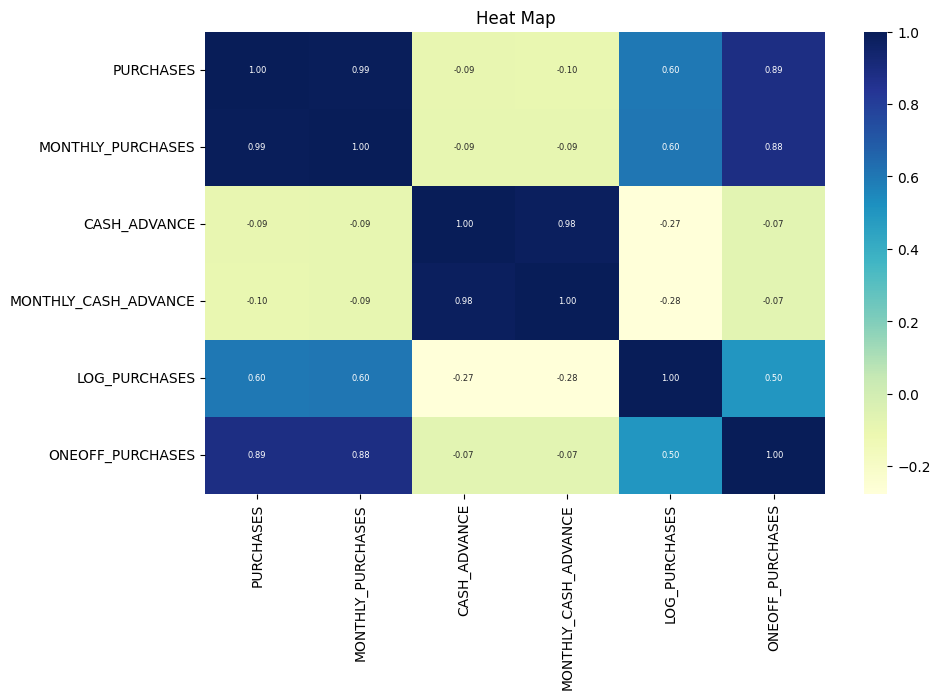

In [94]:
import seaborn as sns



# Create the heatmap
plt.figure(figsize=(10, 6))
plt.title('Heat Map')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlGnBu", annot_kws={'size': 6})
plt.show()

In [95]:
df = df.drop(columns=['MONTHLY_PURCHASES', 'MONTHLY_CASH_ADVANCE'])

In [96]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,ONEOFF_PURCHASE_RATIO,INSTALLMENT_PURCHASE_RATIO,CASH_ADVANCE_TO_CREDIT_RATIO,AVG_PURCHASE_PER_TRX,AVG_CASH_ADVANCE_PER_TRX,LOG_BALANCE,LOG_PURCHASES,LOG_CASH_ADVANCE,LOG_CREDIT_LIMIT,LOG_PAYMENTS
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,...,0.0,1.0,0.000000,47.700000,0.000000,3.735304,4.568506,0.000000,6.908755,5.312231
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,...,0.0,0.0,0.920421,0.000000,1610.736371,8.071989,0.000000,8.770896,8.853808,8.319725
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,...,1.0,0.0,0.000000,64.430833,0.000000,7.822504,6.651791,0.000000,8.922792,6.434654
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,...,1.0,0.0,0.000000,16.000000,0.000000,6.707735,2.833213,0.000000,7.090910,6.521114
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,...,0.0,1.0,0.000000,166.660000,0.000000,7.501540,7.196147,0.000000,7.496097,7.244983


In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

Finding and evaluating k

1.   Elbow method to find the ideal number of clusters
2.   silhouette score to find how similar the data points are in each cluster



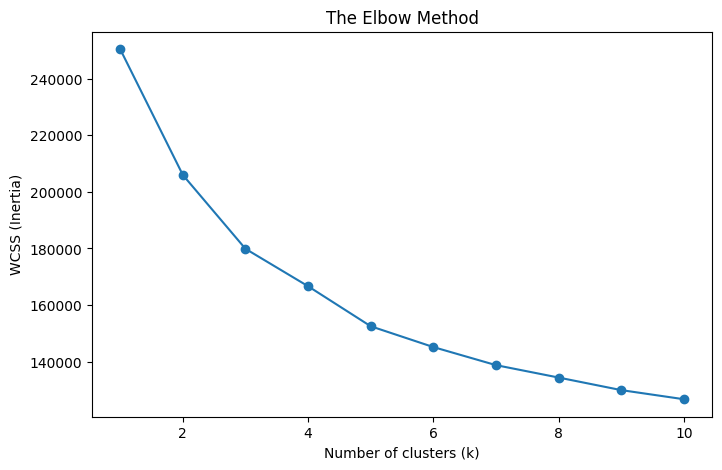

In [98]:
from sklearn.cluster import KMeans

# elbow method
X = df_scaled
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)  # Replace X with your dataset
    wcss.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()


In [99]:
from sklearn.metrics import silhouette_score

#silhouette_score
X = df

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# Calculate Silhouette Score
score = silhouette_score(X, labels, metric='euclidean')

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3840


#Training the model

In [105]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(df_scaled)
df['Cluster'] = kmeans.labels_


In [104]:
kmeans.labels_

array([1, 0, 3, ..., 1, 1, 1], dtype=int32)

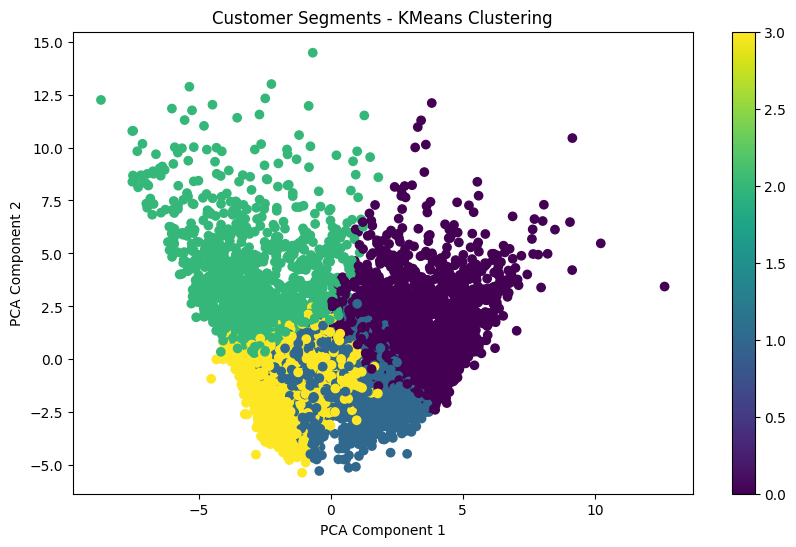

In [107]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(pca_result[:,0], pca_result[:,1], c=df['Cluster'], cmap='viridis')
plt.colorbar(scatter)
plt.title('Customer Segments - KMeans Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [113]:
df['Cluster'].unique()

array([3, 0, 1, 2], dtype=int32)

In [109]:
cluster_details = df.groupby('Cluster').mean()
print(cluster_details)

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        3437.584670           0.943583   317.814010        175.422377   
1         966.197269           0.855480   401.711617        367.823686   
2        2218.028469           0.976923  3716.894201       2394.186398   
3         476.325963           0.858356   646.717700         98.081865   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    141.266934   3309.620038             0.224401   
1                     34.034524    308.969491             0.245079   
2                   1216.717763    442.897368             0.915801   
3                    549.223179     74.452500             0.754392   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                      

In [120]:
# update the cluster column to match the defined categories


cluster_names = {
    0: 'High Risk High Cash Advance',
    1: 'Low Spend Low Risk',
    2: 'High Spend Low Risk',
    3: 'Moderate Spend Low Risk'
}

df['Cluster'] = df['Cluster'].map(cluster_names)

In [116]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,INSTALLMENT_PURCHASE_RATIO,CASH_ADVANCE_TO_CREDIT_RATIO,AVG_PURCHASE_PER_TRX,AVG_CASH_ADVANCE_PER_TRX,LOG_BALANCE,LOG_PURCHASES,LOG_CASH_ADVANCE,LOG_CREDIT_LIMIT,LOG_PAYMENTS,Cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,...,1.0,0.000000,47.700000,0.000000,3.735304,4.568506,0.000000,6.908755,5.312231,Moderate Spend Low Risk
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,...,0.0,0.920421,0.000000,1610.736371,8.071989,0.000000,8.770896,8.853808,8.319725,High Risk High Cash Advance
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,...,0.0,0.000000,64.430833,0.000000,7.822504,6.651791,0.000000,8.922792,6.434654,Low Spend Low Risk
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,...,0.0,0.000000,16.000000,0.000000,6.707735,2.833213,0.000000,7.090910,6.521114,Low Spend Low Risk
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,...,1.0,0.000000,166.660000,0.000000,7.501540,7.196147,0.000000,7.496097,7.244983,Moderate Spend Low Risk
